# Orbital Debris Database: Exploring the Landscape

**Database:** orbital_debris.db (SQLite)  
**Docs:** See quick reports in notebook 04 and data dictionary in `docs/schema` for full schema and field definitions.

**Goal:** Surface patterns, outliers, and new questions in the orbital debris database to guide deeper analysis and visualization.

**Method:**
- For each supporting question, clearly define the analytic goal and specify the relevant database fields.
- Write and execute SQL or pandas queries to extract the required data.
- Validate results by checking row/column counts, nulls, outliers, and consistency with known totals.
- Visualize results with clear, labeled charts or tables appropriate to the question (e.g., time series, histograms, bar charts).
- Document findings, note any data limitations or uncertainties, and flag anomalies for follow-up.

### Why this notebook?
This notebook builds on the cleaned, joined database. Instead of repeating full audits, it focuses on targeted exploration, query prototyping, and visual storytelling to support research questions and analysis.

### What we do here
1. **Prototype questions:** Use SQL and pandas to dig into specific trends, outliers, or hypotheses.
2. **Visualize:** Create quick charts to spot patterns and inform next steps.
3. **Document findings:** Save useful queries, charts, and notes for future reference.

*For table structure, nulls, and sample data, see the end of notebook 04 and the data dictionary.*

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3 as sql
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

plt.rcParams.update({
    "grid.alpha": 0.3,
    "axes.facecolor": "#333333",
    "figure.facecolor": "#333333",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "#333333",
    "legend.edgecolor": "white"
})
 
orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

**Note:** Full quick reports for all database tables are generated at the end of notebook 04 (`04_orbital_debris_synthesis.ipynb`). See that notebook for detailed table structure, nulls, and sample data. For field definitions and schema details, refer to the data dictionary in `docs/schema`. This notebook focuses on exploration and analysis.

## Decoupling Point in Orbital Growth

**Intent:** Identify when the growth of orbital objects shifted from linear to exponential, and characterize how the mix of object types has changed over time. This helps pinpoint inflection points and drivers of congestion in Earth orbit.

**Checklist:**
- Launch Year Trends: Number of objects launched per year (line/bar chart)
- Debris Growth Over Time: Trend of debris objects by year
- Object Type Distribution: How the mix of payloads, rocket bodies, and debris changes over time
- Linear vs Exponential Trend: Visualize trend shift / decoupling point (2014) using curve fit and best split year.

In [19]:
# Query: Launches per year
launches_per_year_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_launches_per_year = pd.read_sql_query(launches_per_year_query, orbital_debris_conn)

# Convert to datetime and extract year
df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year

df_launches_per_year.to_parquet('../data/clean/results/launches_per_year_exp.parquet', index=False)

### Launch Year Trends

**Intent:** Visualize the number of objects launched per year to identify trends, growth phases, and potential inflection points in orbital activity.

**Method:**
- Query the database for launch years of all objects.
- Count the number of objects launched each year.
- Plot the results as a line or bar chart to highlight changes over time.

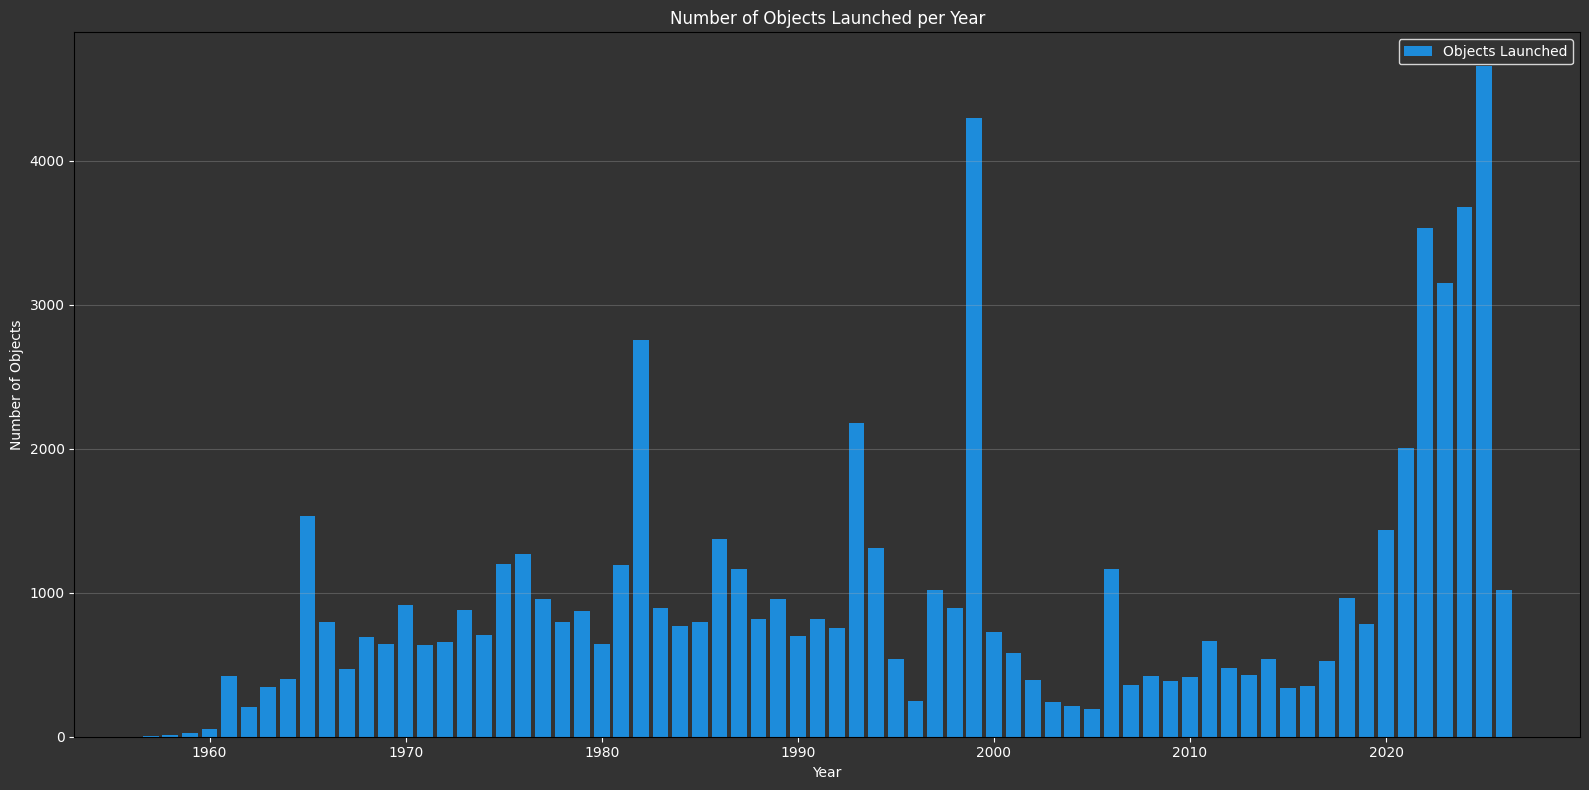

Objects launched per year:
launch_year
1957      3
1958     11
1959     23
1960     52
1961    419
Name: count, dtype: int64


In [20]:
# Count the number of launches per year
if 'launch_date' in df_launches_per_year.columns:
  df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year
  launch_counts = df_launches_per_year['launch_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))
  
  plt.bar(launch_counts.index, launch_counts.values, color="#1d8cdb", label='Objects Launched')

  plt.title('Number of Objects Launched per Year')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend()
  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/launches_per_year_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/launches_per_year_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
  
  print(f'Objects launched per year:\n{launch_counts.head()}')
else:
  print('launch_date column not found in launches data.')

### Debris Growth Over Time: Annual Debris Object Counts

**Intent:** Visualize the trend of debris objects in orbit by year to identify growth patterns and inflection points.

**Method:**
- Query the debris table (or filter satellites table for debris type) for object type = 'DEBRIS'.
- Extract/convert launch or identification year.
- Count and plot the number of debris objects per year.

In [ ]:
# Query: Debris objects per year
debris_query = """
SELECT
    satellites.norad_id,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'DEBRIS' 
    AND launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_debris_per_year = pd.read_sql_query(debris_query, orbital_debris_conn)

# Convert to datetime and extract year
df_debris_per_year['debris_year'] = pd.to_datetime(df_debris_per_year['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_debris_per_year.to_parquet('../data/clean/results/debris_per_year_exp.parquet', index=False)

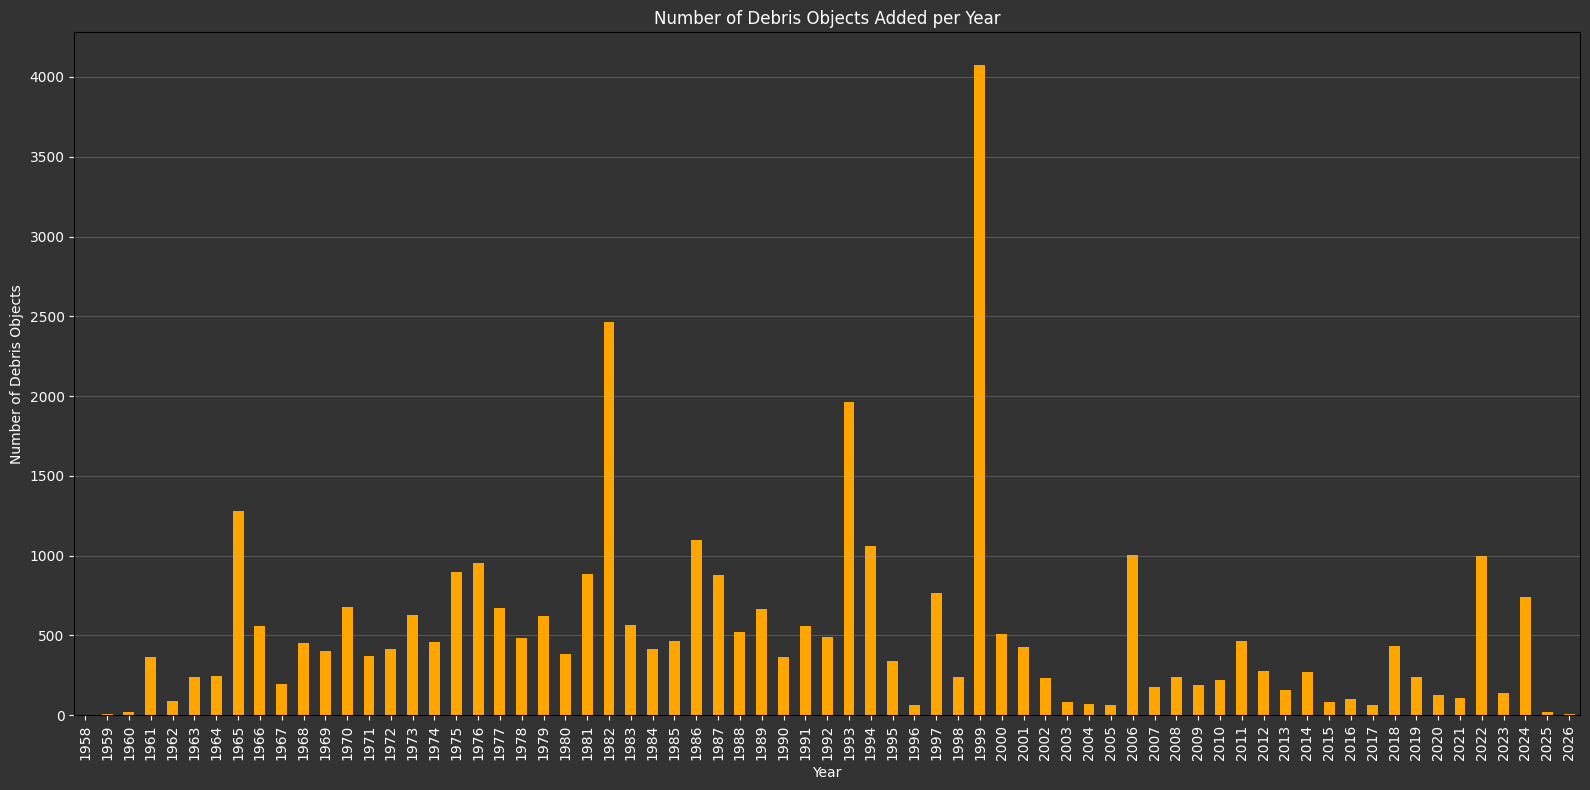

Debris objects added per year:
debris_year
1958      1
1959      5
1960     21
1961    364
1962     88
Name: count, dtype: int64


In [22]:
# Count debris objects per year
if 'launch_date' in df_debris_per_year.columns:
  df_debris_per_year['debris_year'] = pd.to_datetime(df_debris_per_year['launch_date'], errors='coerce').dt.year
  debris_counts = df_debris_per_year['debris_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))

  debris_counts.plot(kind='bar', color='orange')

  plt.title('Number of Debris Objects Added per Year')
  plt.xlabel('Year')
  plt.ylabel('Number of Debris Objects')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/debris_per_year_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/debris_per_year_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
  
  print(f'Debris objects added per year:\n{debris_counts.head()}')
else:
  print('launch_date column not found in debris data.')

### Object Type Distribution: How the Mix of Payloads, Rocket Bodies, and Debris Changes Over Time

**Intent:** Show how the proportions of payloads, rocket bodies, and debris have shifted over time, highlighting changes in the orbital environment.

**Method:**
- Query the satellites table (joined with launch_events) for object type and launch year.
- Group and count by year and object type.
- Visualize as a stacked bar or area chart to show the mix over time.

In [23]:
# Query: Object type distribution by year
object_type_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_type_year = pd.read_sql_query(object_type_query, orbital_debris_conn)

# Convert to datetime and extract year
df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_type_year.to_parquet('../data/clean/results/object_type_year_exp.parquet', index=False)


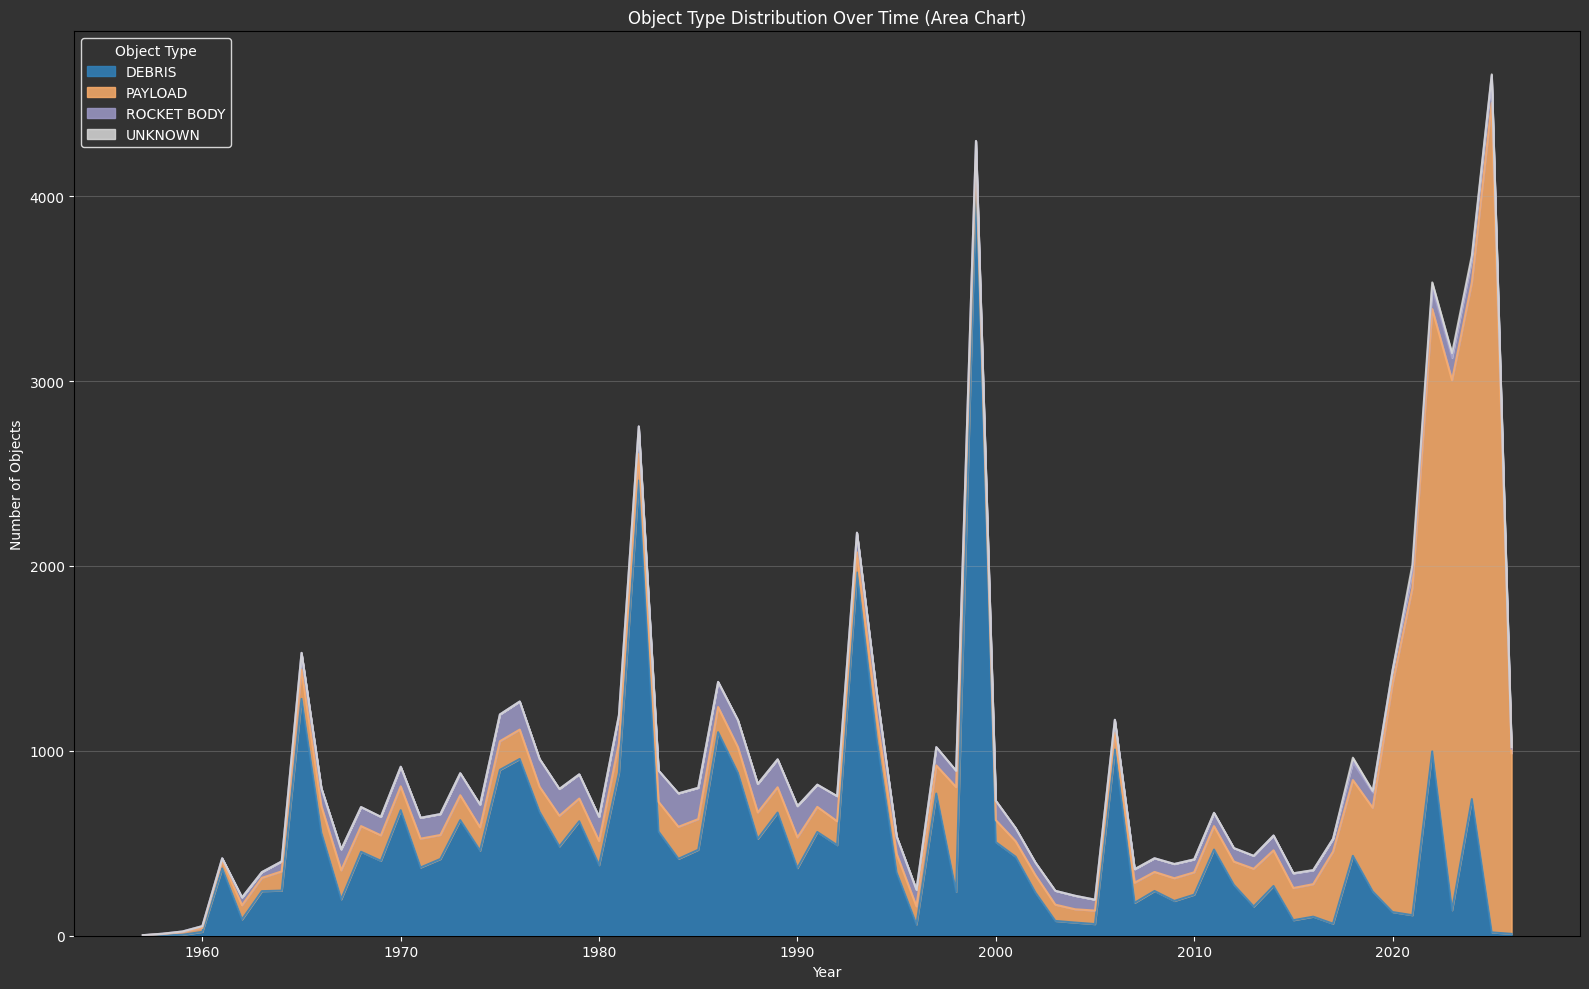

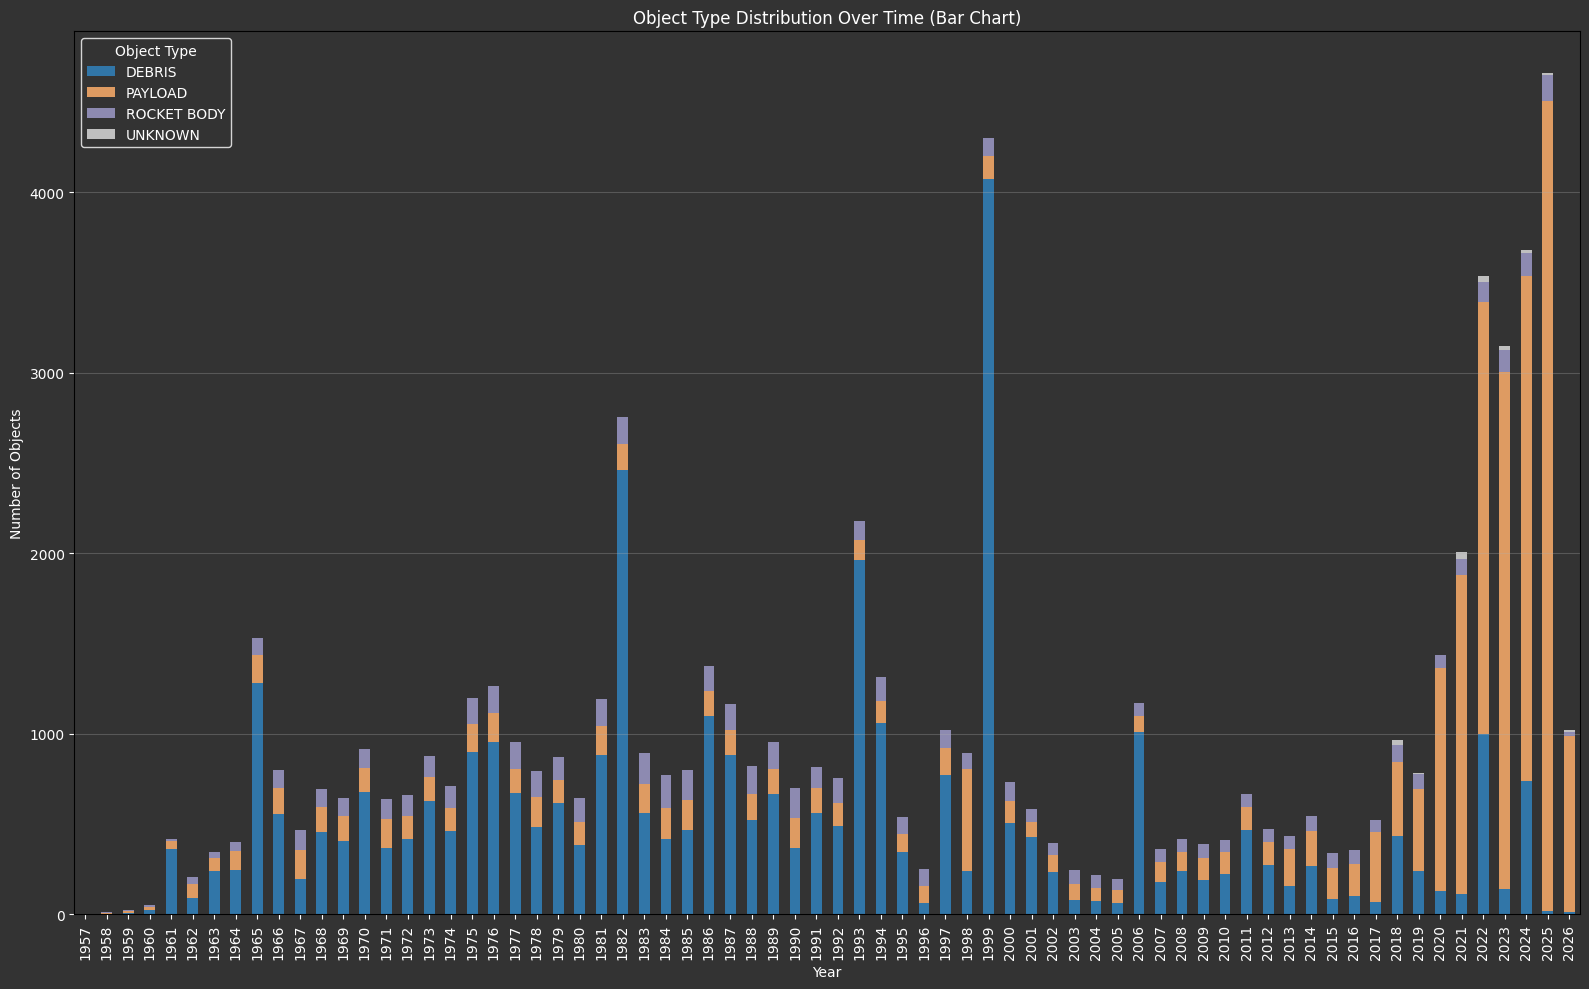

In [24]:
if 'launch_date' in df_type_year.columns and 'object_type' in df_type_year.columns:
  df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

  # Group by year and object type, count
  type_counts = df_type_year.groupby(['launch_year', 'object_type']).size().unstack(fill_value=0)

  # Plot: Stacked area chart
  plt.figure(figsize=(16,10))
  type_counts.plot.area(ax=plt.gca(), alpha=0.85, colormap='tab20c')

  plt.title('Object Type Distribution Over Time (Area Chart)')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/object_type_distribution_exp.png', bbox_inches='tight', dpi=300)
  plt.show()

  # vertical bar chart alternative

  plt.figure(figsize=(16,10))
  type_counts.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.85, colormap='tab20c')

  plt.title('Object Type Distribution Over Time (Bar Chart)')
  plt.xlabel('Year')
  plt.ylabel('Number of Objects')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')

  plt.tight_layout()
  plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_bar_exp.svg', bbox_inches='tight')
  plt.savefig('../charts/questions/exploratory/png/object_type_distribution_bar_exp.png', bbox_inches='tight', dpi=300)
  plt.show()
else:
  print('launch_date or object_type columns not found in type_year table.')

### Linear vs Exponential Trend: In-Orbit Object Growth

**Intent:** Identify and show when the growth of objects in orbit changed from a steady increase (linear) to a much faster rise (exponential), and highlight the year when this shift happened.

**Method:**
- Exclude the current partial year from curve fitting to avoid bias.
- Compute a 3-year rolling average for visual smoothing (not used in fitting).
- Use a data-driven algorithm to select the optimal split year (decoupling point) between linear and exponential regimes.
- Fit a linear trend to the legacy regime (pre-split) and an exponential trend to the modern regime (post-split).
- Plot:
  - Actual in-orbit object counts and 3-year average (lines)
  - Launch missions per year (dashed line)
  - Fitted linear and exponential trends (distinct colors)
  - Vertical line and annotation for the detected split year, with fit diagnostics (slope, growth rate, doubling time)

In [ ]:
# Linear vs Exponential Trend: In-Orbit Object Growth and Annual Launches (with Exponential Fit)
# The Sum .. Case for payload_in_orbit checks the object type, and returns an empty string
# if its null / missing, and then compares it to 'PAYLOAD' to count how many
# payloads are in orbit each year.
linear_vs_exponential_trend_query = """
WITH yearly AS (
  SELECT
    satellites.norad_id,
    launch_events.launch_date AS launch_date,
    launch_events.launch_year AS launch_year,
    satellites.decay_date AS decay_date,
    COUNT(*) AS objects_in_orbit,
    COUNT(DISTINCT launch_events.launch_id) AS launch_missions,
    SUM(
        CASE
          WHEN UPPER(COALESCE(satellites.object_type, '')) = 'PAYLOAD' THEN 1
        ELSE 0
      END
    ) AS payload_in_orbit
  FROM satellites
  JOIN launch_events ON launch_events.launch_id = satellites.launch_id
  WHERE launch_events.launch_year IS NOT NULL
    AND COALESCE(satellites.in_orbit, 0) = 1
  GROUP BY launch_events.launch_year
)
SELECT
  norad_id,
  launch_date,
  launch_year,
  decay_date,
  objects_in_orbit,
  launch_missions,
  payload_in_orbit,
  ROUND(100.0 * payload_in_orbit / NULLIF(objects_in_orbit, 0), 2) AS payload_share_pct,
  SUM(objects_in_orbit) OVER (ORDER BY launch_year) AS cumulative_in_orbit
FROM yearly
ORDER BY launch_year;
"""

df_sat = pd.read_sql_query(linear_vs_exponential_trend_query, orbital_debris_conn)

# Convert to datetime and extract year
df_sat['launch_year'] = pd.to_datetime(df_sat['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_sat.to_parquet('../data/clean/results/linear_vs_exponential_trend_exp.parquet', index=False)

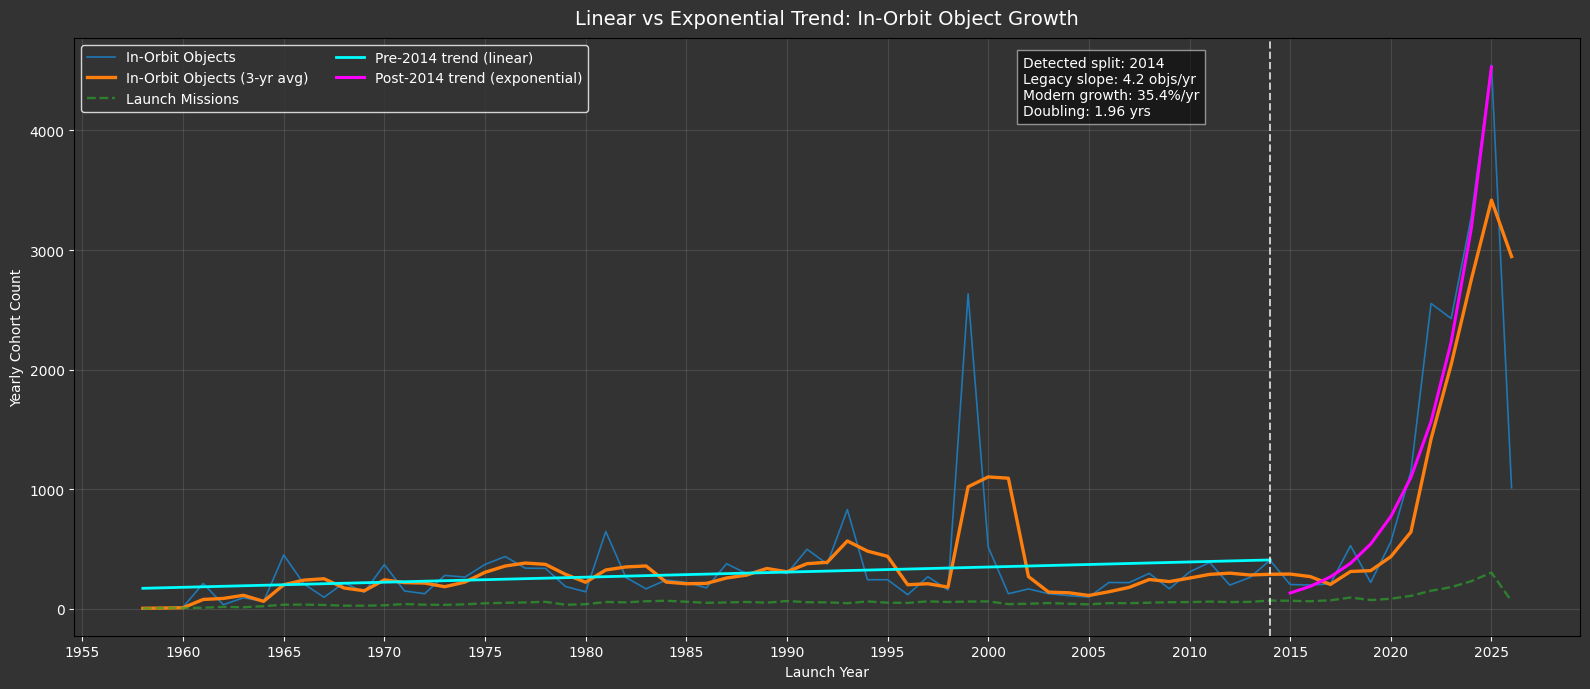

In [35]:
# Exclude the current partial year from fitting.
current_year = pd.Timestamp.now().year
df_sat_fit = df_sat[df_sat['launch_year'] < current_year].copy()

# set up the 3 year rolling average for visual smoothing (but not used in curve fitting).
df_sat['objects_3yr_avg'] = df_sat['objects_in_orbit'].rolling(3, min_periods=1).mean()
df_sat_fit['objects_3yr_avg'] = df_sat_fit['objects_in_orbit'].rolling(3, min_periods=1).mean()

# split selection (no hard coded split year).
split_year, _ = utils.choose_split_year(
    df_sat_fit,
    y_col='objects_in_orbit'
 )

# Fit growth regimes for yearly data, using the selected split year.
pre, post, m_pre, b_exp, doubling_time_years = utils.fit_growth_regimes(
    df_sat_fit,
    split_year=split_year,
    y_col='objects_in_orbit'
 )

fig, ax1 = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='objects_in_orbit',
    linewidth=1.2,
    ax=ax1,
    label='In-Orbit Objects'
 )

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='objects_3yr_avg',
    linewidth=2.4,
    ax=ax1,
    label='In-Orbit Objects (3-yr avg)'
 )

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='launch_missions',
    linewidth=1.7,
    linestyle='--',
    alpha=0.7,
    ax=ax1,
    label='Launch Missions'
 )

sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    ax=ax1,
    color='cyan',
    linewidth=2.0,
    label=f'Pre-{split_year} trend (linear)'
 )

sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    ax=ax1,
    color='magenta',
    linewidth=2.2,
    label=f'Post-{split_year} trend (exponential)'
 )

ax1.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4)

ax1.text(
    0.63, 0.97,
    f'Detected split: {split_year}\n'
    f'Legacy slope: {m_pre:,.1f} objs/yr\n'
    f'Modern growth: {b_exp:.1%}/yr\n'
    f'Doubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
 )

ax1.set_title('Linear vs Exponential Trend: In-Orbit Object Growth', fontsize=14, pad=10)
ax1.set_xlabel('Launch Year')
ax1.set_ylabel('Yearly Cohort Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('../charts/questions/primary/svg/linear_vs_exponential_trend_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/primary/png/linear_vs_exponential_trend_exp.png', bbox_inches='tight', dpi=300)
plt.show()

## High-Risk Object Distribution

**Intent:** Quantify and characterize the distribution of high-risk objects in orbit, focusing on those above velocity and/or kinetic energy thresholds. Assess their prevalence, orbital characteristics, and mass to inform risk assessment and mitigation priorities.

**Checklist:**
- Mass Distribution: Mass of high-risk objects (if available)
- High-Risk Object Counts: Number and share of objects above velocity/kinetic energy thresholds
- Orbit Class Breakdown: Distribution of high-risk objects by orbit class (LEO, MEO, GEO, etc.)
- Altitude Band Analysis: Focus on 400–600 km LEO; histogram or density plot of high-risk objects by altitude

In [ ]:
velocity_threshold = 7800  # m/s
kinetic_energy_threshold = 1e10  # joules

# Query: High-risk objects by velocity or kinetic energy
# We will be adding a row called 'altitude_km' which ( apogee + perigee ) /  2, 
# using the mean of perigee and apogee to estimate an object’s “typical” or “representative” 
# orbital altitude is standard practice in both academic literature and NASA/ESA data analysis.

high_risk_query = f'''
SELECT
  satellites.norad_id,
  satellites.object_name,
  satellites.object_type,
  satellites.in_orbit,
  launch_events.launch_date,
  orbital_data.orbit_class,
  orbital_data.apogee_km,
  orbital_data.perigee_km,
  orbital_data.proxy_mass_kg,
  (orbital_data.apogee_km + orbital_data.perigee_km) / 2 AS altitude_km,
  risk_assessment.velocity_kms,
  risk_assessment.kinetic_joules
FROM satellites 
JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id 
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE risk_assessment.kinetic_joules IS NOT NULL 
  AND satellites.in_orbit = 1;
'''

df_all_sats = pd.read_sql_query(high_risk_query, orbital_debris_conn)
df_all_sats['launch_year'] = pd.to_datetime(df_all_sats['launch_date'], errors='coerce').dt.year
df_all_sats['risk_category'] = df_all_sats.apply(utils.classify_risk_category, axis=1)

df_high_risk = df_all_sats[
  (df_all_sats['risk_category'] == 'Extremely High Risk')
].copy()

# Save the query result to a parquet file for future use.
df_high_risk.to_parquet('../data/clean/results/high_risk_sats_exp.parquet', index=False)

### High-Risk Object Counts

**Intent:** Quantify the number and proportion of high-risk objects in orbit, defined by exceeding velocity and/or kinetic energy thresholds.

**Method:**
- Count the total number of objects and the subset classified as high-risk based on velocity/kinetic energy criteria.
- Calculate the share of high-risk objects relative to the total population.

In [28]:
# Count and share
total_objects = pd.read_sql_query('SELECT COUNT(*) as n FROM satellites;', orbital_debris_conn)['n'][0]
high_risk_count = len(df_high_risk)
high_risk_share = high_risk_count / total_objects if total_objects else float('nan')

print(f'Total objects with risk data: {len(df_all_sats)}')
print(f'High-risk objects: {high_risk_count} of {total_objects} ({high_risk_share:.2%})')

# Validation
print('Nulls per column:')
display(df_high_risk.isnull().sum())

Total objects with risk data: 33346
High-risk objects: 12737 of 68281 (18.65%)
Nulls per column:


norad_id          0
object_name       0
object_type       0
in_orbit          0
launch_date       0
orbit_class       0
apogee_km         0
perigee_km        0
proxy_mass_kg     0
altitude_km       0
velocity_kms      0
kinetic_joules    0
launch_year       0
risk_category     0
dtype: int64

### Mass Distribution: High-Risk Objects

**Intent:** Show the mass distribution of extremely high-risk objects in orbit, highlighting outliers and differences by orbit class.

**Method:**
- Filter for "Extremely High Risk" objects (by velocity/kinetic energy).
- Use available mass and orbit class data.
- Plot histogram (log scale) and strip plot by orbit class.

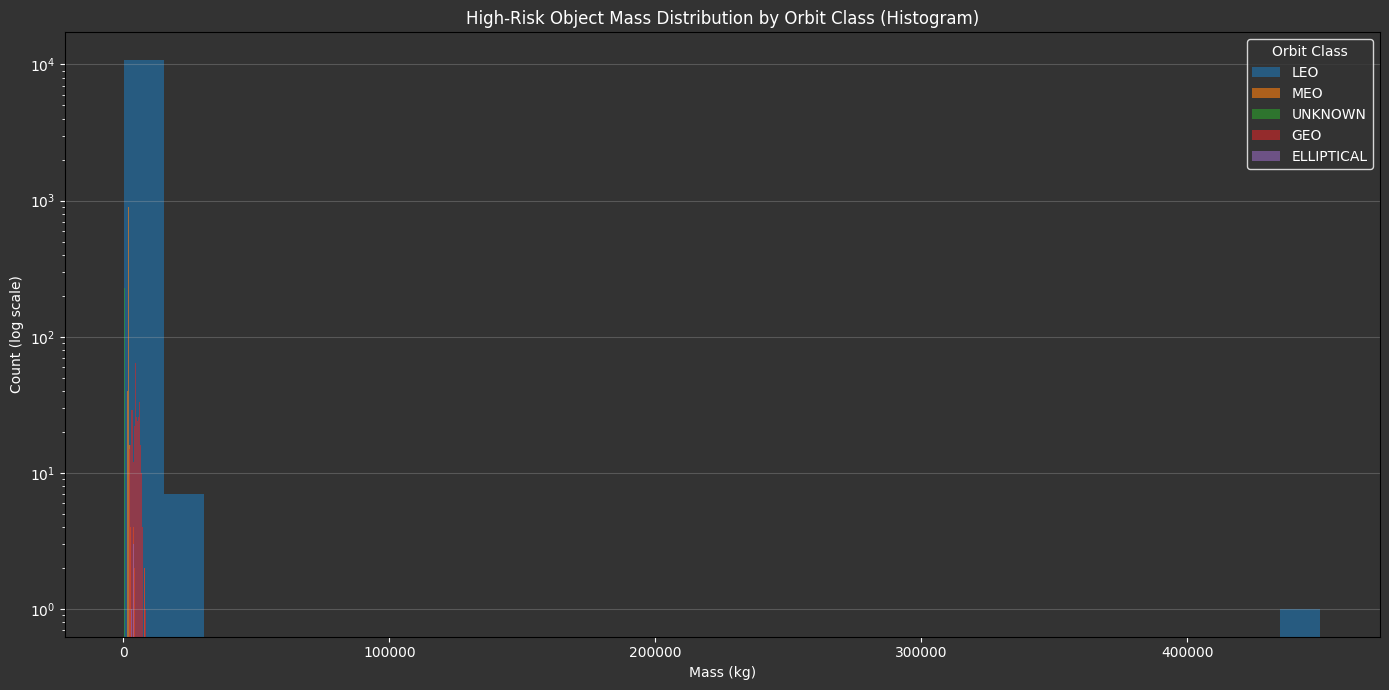

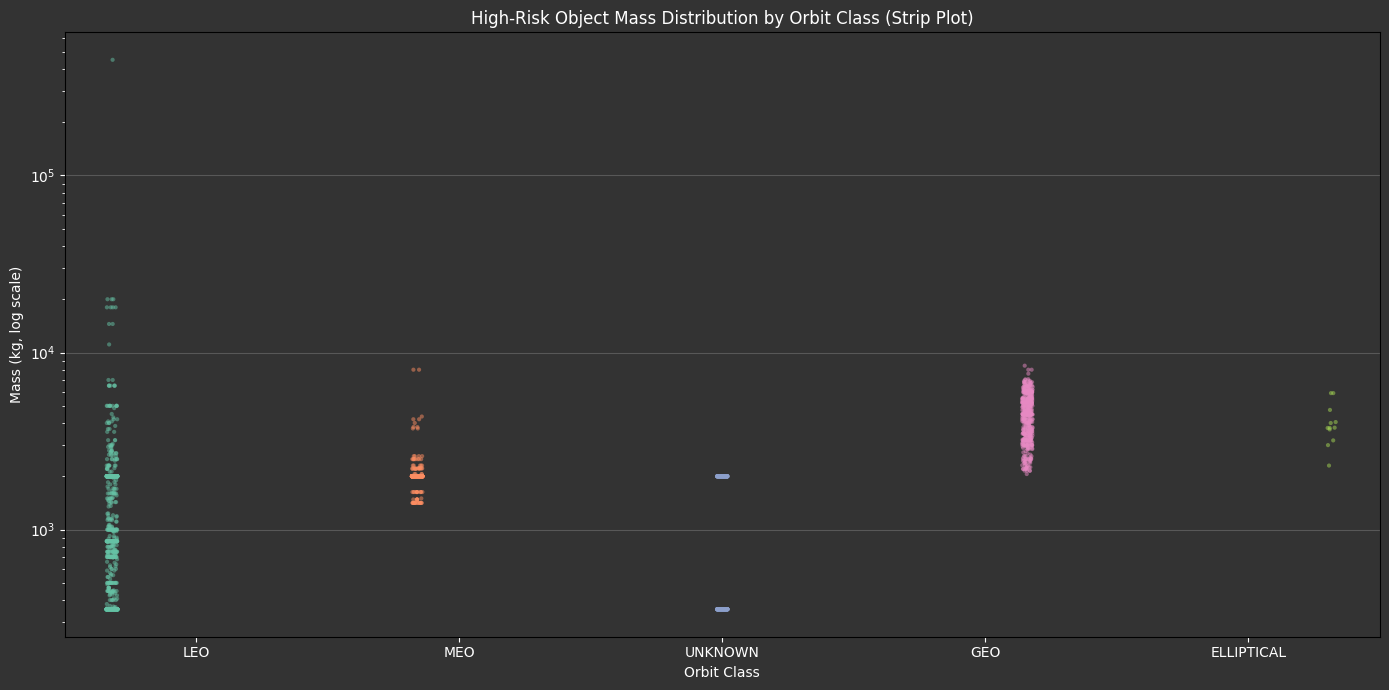

Objects with nonzero mass and orbit class: 12737


In [29]:
# Mass distribution for high-risk objects: histogram and strip plot by orbit_class
if 'proxy_mass_kg' in df_high_risk.columns and 'orbit_class' in df_high_risk.columns:
    mass_nonzero = df_high_risk[['proxy_mass_kg', 'orbit_class']].dropna()
    mass_nonzero = mass_nonzero[mass_nonzero['proxy_mass_kg'] > 0]
    
    # Histogram (all high-risk masses, colored by orbit_class)
    plt.figure(figsize=(14, 7))
    
    for oc in mass_nonzero['orbit_class'].unique():
        subset = mass_nonzero[mass_nonzero['orbit_class'] == oc]
        plt.hist(subset['proxy_mass_kg'], bins=30, alpha=0.6, label=oc)
        
    plt.yscale('log')
    plt.xlabel('Mass (kg)')
    plt.ylabel('Count (log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Histogram)')
    plt.legend(title='Orbit Class')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_hist_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_hist_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Strip plot (each point = object, grouped by orbit_class)
    plt.figure(figsize=(14, 7))
    sns.stripplot(x='orbit_class', y='proxy_mass_kg', data=mass_nonzero, hue='orbit_class', palette='Set2', size=3, dodge=True, alpha=0.5)
    plt.yscale('log')
    plt.xlabel('Orbit Class')
    plt.ylabel('Mass (kg, log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Strip Plot)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_strip_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_strip_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects with nonzero mass and orbit class: {len(mass_nonzero)}')
else:
    print('proxy_mass_kg or orbit_class column not found in high-risk data.')

### Orbit Class Breakdown: High-Risk Objects by Orbit Class

**Intent:** Show how high-risk objects are distributed across orbit classes (LEO, MEO, GEO, etc.).

**Method:**
- Use the high-risk subset from above.
- Group and count by orbit class.
- Visualize as a bar chart or pie chart.

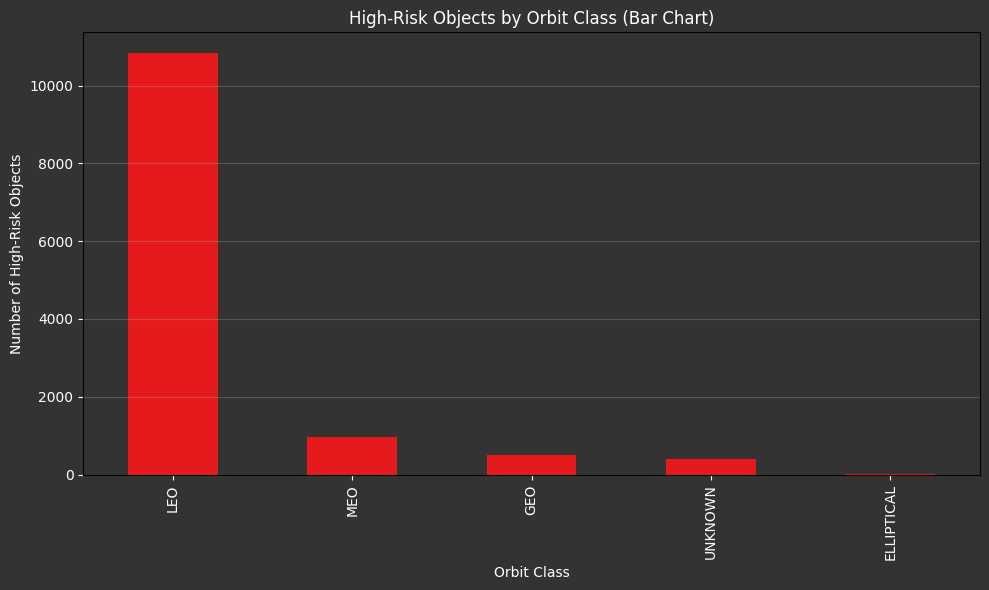

In [30]:
# Group high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    orbit_counts.plot(kind='bar', colormap='Set1')
    
    plt.title('High-Risk Objects by Orbit Class (Bar Chart)')
    plt.xlabel('Orbit Class')
    plt.ylabel('Number of High-Risk Objects')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/hr_orbit_class_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/hr_orbit_class_exp.png', bbox_inches='tight', dpi=300)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

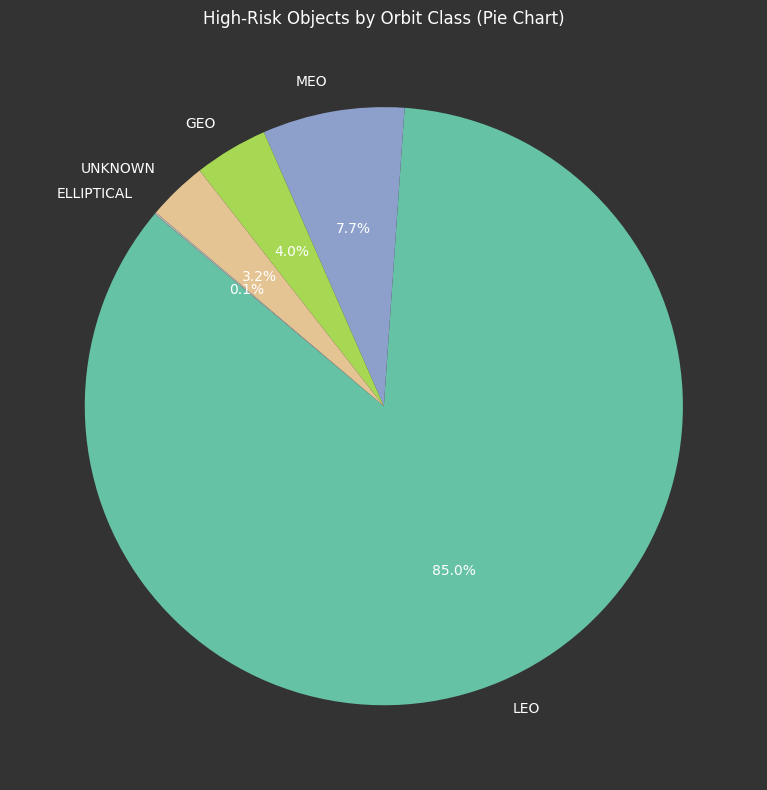

In [31]:
# pie chart of high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts()
    
    plt.figure(figsize=(8,8))
    orbit_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Set2')
    
    plt.title('High-Risk Objects by Orbit Class (Pie Chart)')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/hr_orbit_class_pie_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/hr_orbit_class_pie_exp.png', bbox_inches='tight', dpi=300)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

### Altitude Band Analysis: 400–600 km LEO High-Risk Objects

**Intent:** Focus on high-risk objects in the 400–600 km altitude band (LEO), a region of particular congestion and risk.

**Method:**
- Filter high-risk objects for those with altitude between 400 and 600 km.
- Plot histogram or density plot of their altitudes.

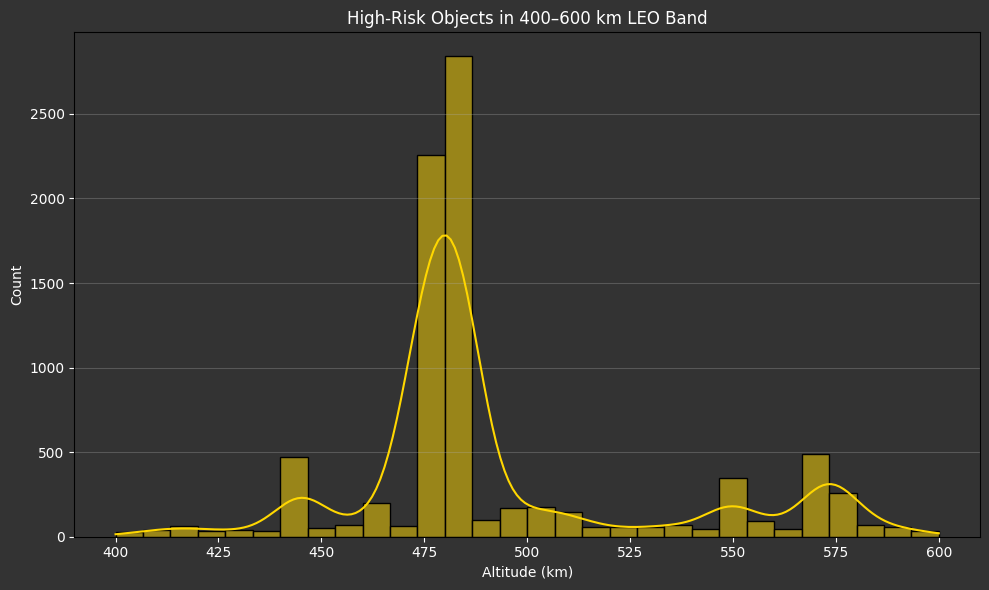

Objects in 400 - 600 km band: 8463


In [32]:
# Filter for 400–600 km LEO high-risk objects
if 'altitude_km' in df_high_risk.columns:
    leo_band = df_high_risk[(df_high_risk['altitude_km'] >= 400) & (df_high_risk['altitude_km'] <= 600)]
    
    plt.figure(figsize=(10,6))
    sns.histplot(leo_band['altitude_km'], bins=30, kde=True, color='gold')
    
    plt.title('High-Risk Objects in 400–600 km LEO Band')
    plt.xlabel('Altitude (km)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_banded_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_banded_exp.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects in 400 - 600 km band: {len(leo_band)}')
else:
    print('altitude column not found in high-risk data.')

## General EDA / Supporting Queries
 
**Intent:** Surface key supporting statistics and patterns to inform risk, context, and further analysis. These queries provide context for the main risk and congestion questions.
 
**Checklist:**
- Mass Accumulation: Launched, Decayed, and Remaining Mass Over Time
- Mass Distribution: Distribution of mass by orbit class and orbit type.
- Country of Origin: Top countries by number of objects in orbit.
- Satellite Age Distribution: Histogram of satellite ages; highlight old/young outliers.
- Largest Single Launch Events: Launches that contributed the most objects.

### Mass Accumulation: Launched, Decayed, and Remaining Mass Over Time

**Intent:** Show the full lifecycle of orbital mass: how much is launched each year, how much decays (re-enters) each year, and how much remains in orbit at any given time.

**Method:**
- Bar chart: annual mass launched (blue) and annual mass decayed (orange), side by side for each year.
- Line: cumulative mass remaining in orbit after accounting for launches and decays (lime).

This visual provides a direct comparison of the inflow (launches), outflow (decays), and net accumulation of mass in Earth's orbit over time.

In [33]:
mass_over_time_query = """
SELECT
    satellites.norad_id,
    satellites.decay_date,
    satellites.in_orbit,
    orbital_data.proxy_mass_kg,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_mass_over_time = pd.read_sql_query(mass_over_time_query, orbital_debris_conn)

# Convert to datetime and extract year
df_mass_over_time['launch_year'] = pd.to_datetime(df_mass_over_time['launch_date'], errors='coerce').dt.year

df_mass_over_time.to_parquet('../data/clean/results/mass_over_time_exp.parquet', index=False)

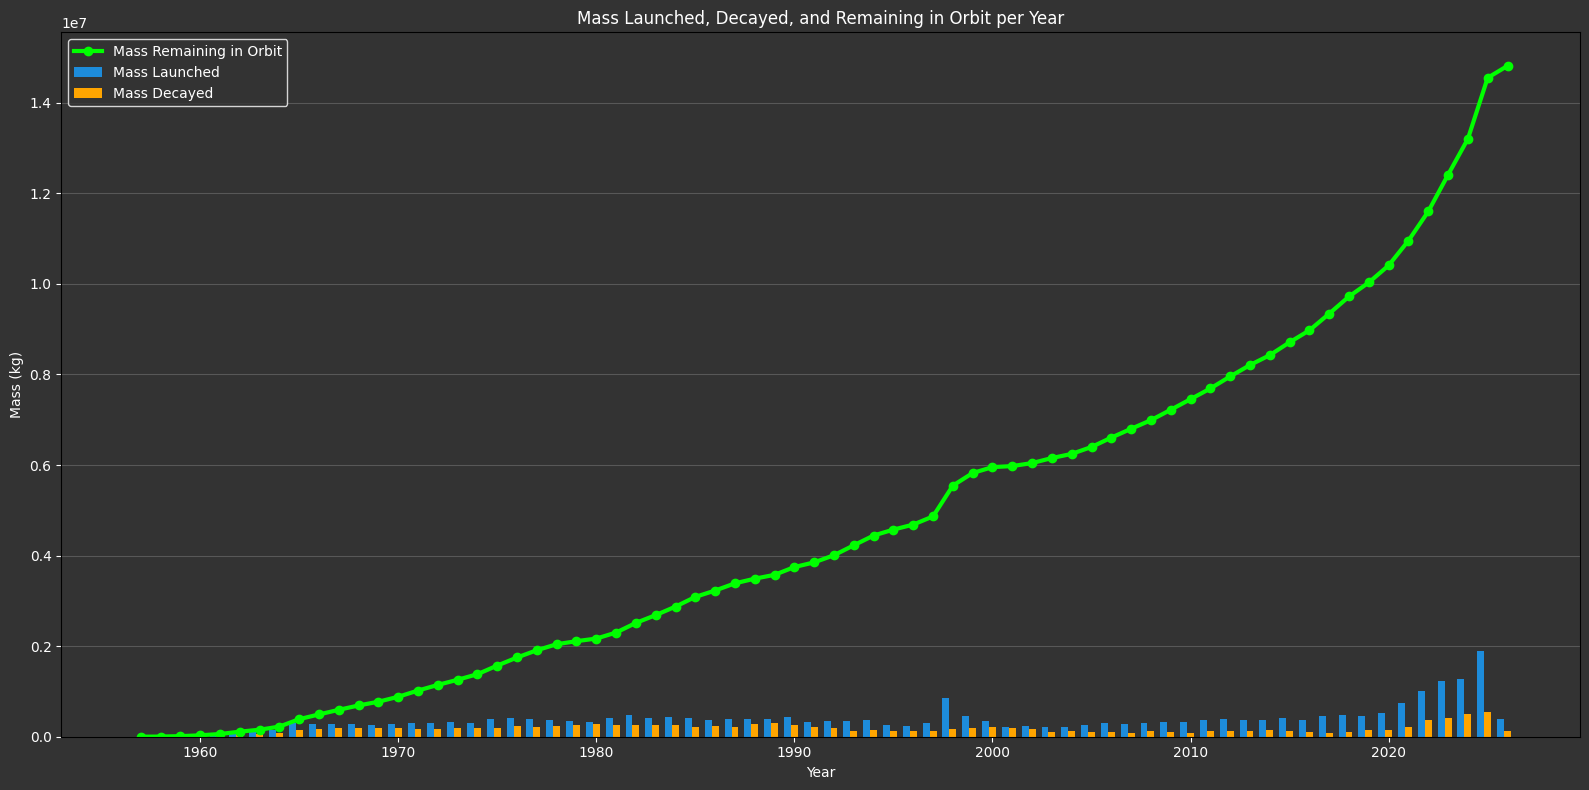

Total mass launched: 27,055,099 kg
Total mass decayed: 12,240,007 kg
Mass remaining in orbit (as of 2026): 14,815,092 kg


In [34]:
# Combined chart: Mass Launched, Mass Decayed, and Mass Remaining per Year
if ('proxy_mass_kg' in df_mass_over_time.columns and 
    'in_orbit' in df_mass_over_time.columns and
    'decay_date' in df_mass_over_time.columns):
    
    # Mass launched per year
    mass_by_year = df_mass_over_time.groupby('launch_year')['proxy_mass_kg'].sum().sort_index()
    
    # Mass decayed per year
    df_decayed = df_mass_over_time[df_mass_over_time['in_orbit'] == 0].copy()
    df_decayed['decay_year'] = pd.to_datetime(df_decayed['decay_date'], errors='coerce').dt.year
    decayed_by_year = df_decayed.groupby('decay_year')['proxy_mass_kg'].sum().sort_index()

    # Align years for plotting
    all_years = sorted(set(mass_by_year.index).union(decayed_by_year.index))
    mass_launched = mass_by_year.reindex(all_years, fill_value=0)
    mass_decayed = decayed_by_year.reindex(all_years, fill_value=0)

    # Cumulative sums for remaining mass
    cumulative_launched = mass_launched.cumsum()
    cumulative_decayed = mass_decayed.cumsum()
    mass_remaining = cumulative_launched - cumulative_decayed

    plt.figure(figsize=(16,8))
    width = 0.35

    # Bar for mass launched
    plt.bar([y - width for y in all_years], mass_launched.values, width=width, label='Mass Launched', color='#1d8cdb')
    
    # Bar for mass decayed
    plt.bar([y for y in all_years], mass_decayed.values, width=width, label='Mass Decayed', color='orange')
    
    # Line for mass remaining
    plt.plot(all_years, mass_remaining.values, label='Mass Remaining in Orbit', color='lime', linewidth=3, marker='o')

    plt.title('Mass Launched, Decayed, and Remaining in Orbit per Year')
    plt.xlabel('Year')
    plt.ylabel('Mass (kg)')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/mass_launched_decayed_remaining_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/mass_launched_decayed_remaining_exp.png', bbox_inches='tight', dpi=300)
    plt.show()

    print(f'Total mass launched: {mass_launched.sum():,.0f} kg')
    print(f'Total mass decayed: {mass_decayed.sum():,.0f} kg')
    print(f'Mass remaining in orbit (as of {df_mass_over_time["launch_year"].max()}): {mass_remaining.iloc[-1]:,.0f} kg')
else:
    print('proxy_mass_kg, in_orbit, or decay_date column not found in mass over time data.')